In [1]:
import math

import numpy as np
import SimpleITK as sitk
import pyvista as pv
import point_cloud_utils as pcu

from morphometry import hip, utils
from matplotlib import pyplot as plt
from scipy.spatial import KDTree
from scipy.ndimage import center_of_mass
from sklearn.cluster import KMeans
from skimage.measure import find_contours
from pathlib import Path

In [87]:
import importlib
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [33]:
pv.set_jupyter_backend('trame')

# Femoral head center

In [34]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
#  mask = sitk.ReadImage('/home/simon/Data/nnUnet_raw/Dataset001_AugsburgHip/labelsTr/t1_tse_tra_Huften_bds_10mm_PA000006.nii.gz')
spacing = mask.GetSpacing()
x_ratio = abs(spacing[2]) / 2 * abs(spacing[0])

In [35]:
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.where(mask_array == 1, 1, 0)

In [36]:
mask_array.shape

(160, 264, 384)

In [98]:
x_ratio

0.5

Axis order: x = coronal, y = axial, z = sagittal
-> swap x and y

In [37]:
mask_array = np.swapaxes(mask_array, 0, 1)

In [93]:
r, c = hip.get_femoral_head_center(mask_array[:, :, :mask_array.shape[2] // 2], side='left', x_ratio=1, isotropic=True)

In [94]:
r, c

(24.762622763598795, array([184.61651661,  57.73785656,  97.2732263 ]))

In [95]:
point_cloud = np.argwhere(mask_array)
idx = pcu.downsample_point_cloud_poisson_disk(point_cloud.astype('float32'), radius=0, target_num_samples=1000)

In [96]:
# pc = hip.get_femoral_head_center(mask_array[:, :, :mask_array.shape[2] // 2], side='left', x_ratio=x_ratio) / np.array([x_ratio, 1, 1])

In [97]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(mask_array)), color='b')
p.add_mesh(pv.Sphere(r, c))
# p.add_mesh(pv.PolyData(pc), color='red')
p.enable_eye_dome_lighting()
p.show()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:44079/index.html?ui=P_0x7a0d9b5a1660_16&reconnect=auto" class="pyv…

# Femoral shaft axis

In [33]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [39]:
p0, p1 = hip.get_femoral_shaft_axis(mask_array[:, :, :mask_array.shape[2] // 2])

In [40]:
p0, p1

(array([259,  53,  70]), array([239,  60,  60]))

In [41]:
p3 = p0 - p1
p3

array([20, -7, 10])

In [43]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(point_cloud[idx]), color='b')
p.add_lines(np.array([np.array(c), point_cloud[73246]]), color='r')
p.add_lines(np.array([p0, p1 - 3 * p3]), color='g')
p.add_lines(np.array([p0, p1]), color='y')
p.add_mesh(pv.Sphere(r, c))
p.show()

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x79688753e710_7&reconnect=auto" class="pyvi…

# Femoral neck axis

In [55]:
solid_sphere = pv.SolidSphere(inner_radius=1.1*r, outer_radius=1.2 * r, center=c)
points_i_want = np.array(solid_sphere.points)
points_i_want = points_i_want[points_i_want[:, 0] > c[0]]
points_i_want = points_i_want[points_i_want[:, 2] < c[2]]

In [56]:
tmp = pv.PolyData(point_cloud[idx])

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


In [57]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(points_i_want), color='r', opacity=0.5)
p.show()

Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x796844d8ae30_11&reconnect=auto" class="pyv…

In [58]:
pc_tree = KDTree(point_cloud)
sphere_tree = KDTree(points_i_want)

In [59]:
pairs = pc_tree.query_ball_tree(sphere_tree, 2)

In [60]:
neck_points = list()
for pair in pairs:
    if len(pair) > 0:
        for index in pair:
            neck_points.append(sphere_tree.data[index])

neck_points = np.array(neck_points)

In [61]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.show()

Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x796887596950_12&reconnect=auto" class="pyv…

In [62]:
com = KMeans(n_clusters=1).fit(neck_points).cluster_centers_

In [63]:
com

array([[194.96241356,  55.65614839,  76.34680252]])

In [64]:
neck_axis = c - com[0]

In [65]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='y', width=5)
p.show()

Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x796846b6bf40_13&reconnect=auto" class="pyv…

# CCD

In [39]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [66]:
hip.calc_ccd(mask_array[:, :, :mask_array.shape[2] // 2])

92.27907953616051

In [40]:
segmentations = list()
for path in Path('/home/simon/Data/Hamburg').iterdir():
    for file in path.iterdir():
        if 'Segmentation' in file.name:
            segmentations.append(file)

# Alpha angle

In [67]:
most_proximal_points = neck_points[neck_points[:, 0] == neck_points[:, 0].min()]
most_proximal_lateral_point = most_proximal_points[most_proximal_points[:, 2] == most_proximal_points[:, 2].max()]

In [68]:
most_proximal_lateral_point[0]

array([183.85483948,  55.20056174,  72.02023674])

In [69]:
v1 = c - com[0]
v2 = c - most_proximal_lateral_point[0]
v1, v2

(array([-11.26489602,   2.44604579,  22.39269008]),
 array([-0.15732194,  2.90163245, 26.71925586]))

In [70]:
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)

In [71]:
angle = np.arccos(np.dot(v1, v2))
math.degrees(angle)

26.23366463058165

In [74]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='y', width=5)
p.add_lines(np.array([c, most_proximal_lateral_point[0]]), color='y', width=5)
p.show()

Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x79688753d1e0_16&reconnect=auto" class="pyv…

In [108]:
p.close()

# Acetabular Anteversion

In [75]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [77]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
spacing = mask.GetSpacing()
z_ratio = abs(spacing[2]) / 2 * abs(spacing[0])
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.swapaxes(mask_array, 0, 1)

In [78]:
mask_array.shape

(264, 160, 384)

In [79]:
femur_array = np.where(mask_array == 1, 1, 0)

In [80]:
acetabulum_array = np.where(mask_array == 3, 3, 0)

In [81]:
left_femur = femur_array[:, :, :femur_array.shape[2] // 2]
right_femur = femur_array[:, :, femur_array.shape[2] // 2:]

In [82]:
left_acetabulum = acetabulum_array[:, :, :acetabulum_array.shape[2] // 2]
right_acetabulum = acetabulum_array[:, :, acetabulum_array.shape[2] // 2:]

In [83]:
left_femur.shape

(264, 160, 192)

In [84]:
lr, left_fhc = hip.get_femoral_head_center(left_femur, 'left')
rr, right_fhc = hip.get_femoral_head_center(right_femur, 'right')

In [85]:
left_fhc, right_fhc

(array([183.69751754,  58.10219419,  98.7394926 ]),
 array([189.22227829,  57.36492729,  92.6464867 ]))

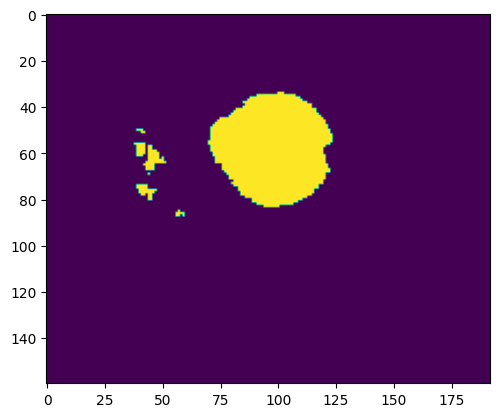

In [86]:
plt.imshow(left_femur[int(left_fhc[0])])

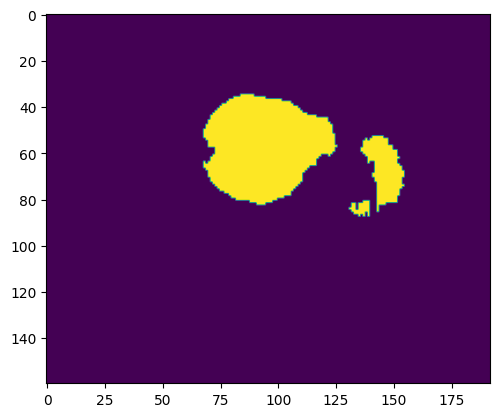

In [87]:
plt.imshow(right_femur[int(right_fhc[0])])

In [88]:
slice_gap = abs(int(left_fhc[0]) - int(right_fhc[0]))
slice_gap

6

In [89]:
correct_slice = min(int(left_fhc[0]), int(right_fhc[0])) + slice_gap // 2
correct_slice

186

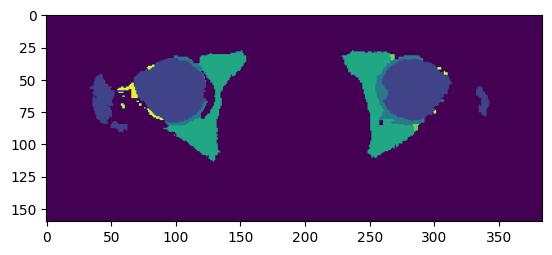

In [90]:
plt.imshow(mask_array[correct_slice])

Do left side first

In [91]:
p1_left = np.argwhere(left_acetabulum[correct_slice])
p1_left = p1_left[p1_left[:, 1].argmin()]
p1_left

array([88, 91])

In [92]:
p2_left = np.argwhere(left_acetabulum[correct_slice][:left_acetabulum.shape[1] // 3])
p2_left = p2_left[p2_left[:, 1].argmin()]
p2_left

array([ 38, 118])

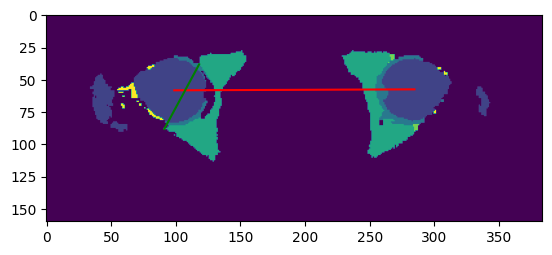

In [93]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_left[1], p2_left[1]], [p1_left[0], p2_left[0]], 'g')
plt.show()

In [94]:
right_fhc_adj = right_fhc.copy()
right_fhc_adj[2] += left_femur.shape[2]
G = left_fhc[1:] - right_fhc_adj[1:]
G

array([   0.73726689, -185.9069941 ])

In [95]:
# https://math.stackexchange.com/questions/1398634/finding-a-perpendicular-vector-from-a-line-to-a-point
u = left_fhc[1:]
v = G
P = p1_left
P_  = np.dot(np.dot((P - u), v) / np.dot(v, v), v) + u
t = P - P_
t

array([29.86664293,  0.11844464])

In [96]:
np.dot(G, t)

np.float64(-2.1316282072803006e-13)

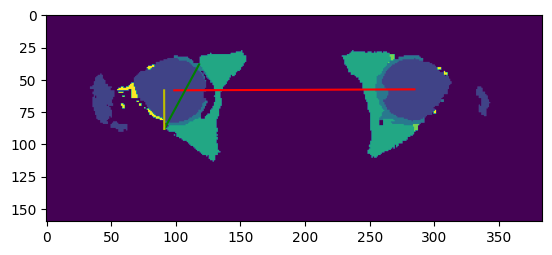

In [97]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_left[1], p2_left[1]], [p1_left[0], p2_left[0]], 'g')
plt.plot([p1_left[1], p1_left[1] - t[1]], [p1_left[0], p1_left[0] - t[0]], 'y')
plt.show()

In [98]:
v1 = (p1_left - p2_left).astype('float32')
v2 = t.copy()
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)
math.degrees(np.arccos(np.dot(v1, v2)))

28.59626716249661

Then right side

In [99]:
p1_right = np.argwhere(right_acetabulum[correct_slice])
p1_right = p1_right[p1_right[:, 1].argmax()]
p1_right

array([87, 92])

In [100]:
p2_right = np.argwhere(right_acetabulum[correct_slice][:right_acetabulum.shape[1] // 3])
p2_right = p2_right[p2_right[:, 1].argmax()]
p2_right

array([33, 74])

In [101]:
u = right_fhc[1:]
v = G
P = p1_right
P_  = np.dot(np.dot((P - u), v) / np.dot(v, v), v) + u
t = P - P_
t

array([29.63204284,  0.11751427])

In [102]:
np.dot(G, t)

np.float64(9.841016890277388e-13)

In [103]:
plt.show()
v1 = (p1_right - p2_right).astype('float32')
v2 = t.copy()
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)
math.degrees(np.arccos(np.dot(v1, v2)))

18.207723061604835

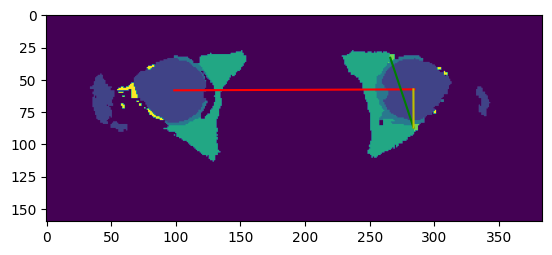

In [104]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_right[1] + left_femur.shape[2], p2_right[1] + left_femur.shape[2]], [p1_right[0], p2_right[0]], 'g')
plt.plot([p1_right[1] + left_femur.shape[2], p1_right[1] + left_femur.shape[2] - t[1]], [p1_right[0], p1_right[0] - t[0]], 'y')
plt.show()

# Center Edge Angle

In [106]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.swapaxes(mask_array, 0, 1)

In [107]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [108]:
femur_array = np.where(mask_array == 1, 1, 0)
acetabulum_array = np.where(mask_array == 3, 1, 0)

left_femur = femur_array[:, :, :femur_array.shape[2] // 2]
right_femur = femur_array[:, :, femur_array.shape[2] // 2:]

left_acetabulum = acetabulum_array[:, :, :acetabulum_array.shape[2] // 2]
right_acetabulum = acetabulum_array[:, :, acetabulum_array.shape[2] // 2:]

_, left_fhc = hip.get_femoral_head_center(left_femur, 'left')
_, right_fhc = hip.get_femoral_head_center(right_femur, 'right')

right_fhc_adj = right_fhc.copy()
right_fhc_adj[2] += left_femur.shape[
    2]  # adjust the x coordinate of the right femoral head center to account for the splitting into left and right
G = left_fhc - right_fhc_adj  # G is the vector connecting the left and right femoral head center

In [109]:
u = right_fhc
v = G
p = right_fhc + np.array([-1, 0, 0])
s = hip.get_vector_through_point_perpendicular_to_line(u, v, p)  # s is perpendicular to G and goes in proximal direction
np.dot(G, s)

np.float64(4.147793219999585e-13)

In [110]:
most_proximal_femur_slice = np.min(np.nonzero(right_femur)[0])
acetabulum_points = np.nonzero(right_acetabulum[most_proximal_femur_slice - 10:most_proximal_femur_slice + 10])
lateral_edge = np.argmax(acetabulum_points[2])
lateral_edge_point = np.array([acetabulum_points[0][lateral_edge] + most_proximal_femur_slice, acetabulum_points[1][lateral_edge], acetabulum_points[2][lateral_edge]])
lateral_edge_point

array([165,  57, 106])

In [111]:
s2 = right_fhc - lateral_edge_point


In [112]:
utils.calc_angle_between_vectors(np.abs(s), s2)

30.577980219396476

In [113]:
s2

array([ 0.87566203,  0.01319252, -0.48274421])

In [114]:
s

array([-9.99117641e-01, -1.17748816e-04,  2.96911858e-02])

In [115]:
p = pv.Plotter()
p.add_lines(np.array([left_fhc, right_fhc_adj]), color='y')
p.add_lines(np.array([right_fhc_adj, right_fhc_adj + 10 * s]), color='r')
p.add_lines(np.array([right_fhc_adj, lateral_edge_point + np.array([0, 0, left_femur.shape[2]])]), color='g')
p.show()

Widget(value='<iframe src="http://localhost:44467/index.html?ui=P_0x796846b79600_17&reconnect=auto" class="pyv…